In [ ]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys #首先，添加路径，windows的路径和linux的路径符号不同\\,/,注意区别  #r是为了告诉python这是路径，别#把\n等特殊组合给转译）
sys.path.append(r"./main_code")
import generate_data2,grid_cell,adaptive_int,visual,cal_S_grad,org_m,mea_2D,net_2D_shape,S_valgrad,error_general_ada,main,ass_grad
CUDA_LAUNCH_BLOCKING=1
def f_circle(x,x_left,x_right,y_below,y_upper,center,r):
    # Compute r_y = sqrt((x1 - y1)^2 + (x2 - y2)^2 + (x3 - y3)^2)
    r_y = np.linalg.norm(x - center, axis=-1)
    # Apply the piecewise function
    f_y_values = np.where(r_y < r , 1.0, 0.0)
    return f_y_values

cuda:2


/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/_environment.py:541: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy, cupy-cuda12x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  warnings.warn(f'''


In [5]:
import copy
Nx,Ny=1,1
Ix,Iy=1,1  #x方向网格点
nx,ny=100,100  #每个网格x方向的高斯点
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89]
tau_x_min,tau_x_max,tau_y_min,tau_y_max=0,1,0,1
b_x_min,b_x_max,b_y_min,b_y_max=-0.5,1.5,-0.5,1.5 #边界gamma处

num_batches_gauss=1
b_n=15
points_b=mea_2D.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n) #在边界Γ处收集数据
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.2
center_true=np.array([0.5,0.5])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
cupy_device=2
S_int_true_circle,F_mea_b_circle,F_mea_db_x1_circle,F_mea_db_x2_circle=generate_data2.boundary_data_circle(kk,number_gene,points_b,f_circle,x_left,x_right,y_below,y_upper,center_true,r_true,eps,mea,batch_number_rec_mea,device,cupy_device)
F=org_m.F(F_mea_b_circle,F_mea_db_x1_circle,F_mea_db_x2_circle)

cells= grid_cell.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b) #创造初始网格
initial_cells=copy.deepcopy(cells) #copy一份
R_m=20
r_low,r_upper=0.18,0.2
b_below,b_upper=-0.51,-0.49


In [26]:
M=800
af="Tanh"   #先用tanh
R_m=20
cupy_device= 2
#models = net_2D_shape.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
models = net_2D_shape.local_rep(2,1,1,M,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],R_m_for_init=R_m,af=af,Shape=[],device=device).to(device)

In [35]:
def ada_int(iter_int,delta,cells,nx,models,M,af,kk,F,tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_low,r_upper,center_true,r_true,ana_S,points_b,lamb_regu,Qx,Qy,device,cupy_device):
    cells_store=[]
    Cells=cells
    refinement_stats_store=[]
    leaf_cells=grid_cell.collect_leaf_cells(Cells) #初始叶子节点
    all_points0, all_weights = grid_cell.collect_all_gauss_points(leaf_cells) #初始高斯点
    w_=[]
    point_number=[]
    S_num_store=[]
    S_l2=[]
    S_l_20=0
    g_store=[]
    for i in range(iter_int):
        cells_store.append(Cells)
        point_number.append(all_points0.shape[0])
        g_store.append(all_points0)
        all_mat,all_g_list,all_g_p,Cells,grads_y1,grads_y2=ass_grad.mat_assemble(Cells,models,[],[],af,[],[],kk,0,points_b,0,device,cupy_device) 
        #lamb_regu=np.logspace(-13,-12, 1, endpoint = True) 
        res,reg_norm,w_store=org_m.L_curve(all_mat,F,[],[],[],lamb_regu,"linear",device,cupy_device) #先进行求解
        print("第",i,"次迭代的train误差：")
        return cells_store,all_points0,w_store
       

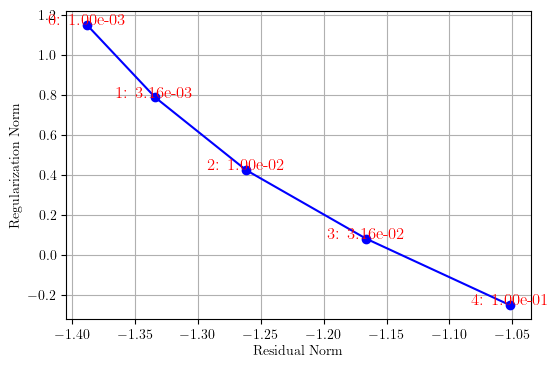

第 0 次迭代的train误差：


In [ ]:
iter_int= 1
delta=10**(-3)
nx=100
lamb_regu=np.logspace(-2,1)
Qx,Qy=150,150
af="Tanh"
cells_store,all_points_0,w_store=ada_int(iter_int,delta,cells,nx,models,M,af,kk,F,tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_low,r_upper,center_true,r_true,f_circle,points_b,lamb_regu,Qx,Qy,device,cupy_device)

In [23]:
w_store.shape

(400, 5)

正则化参数： 0.0001


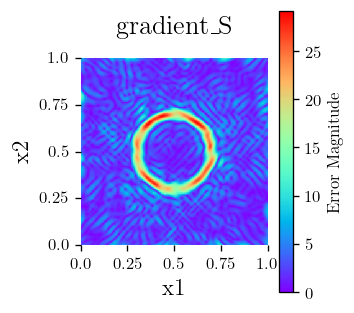

S_l_inf= 1.6386769828218122 S_L_2= 0.07865431923277018 S_l_2= 0.2228829144605322


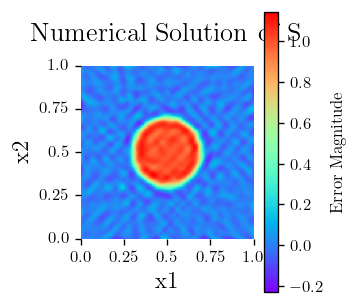

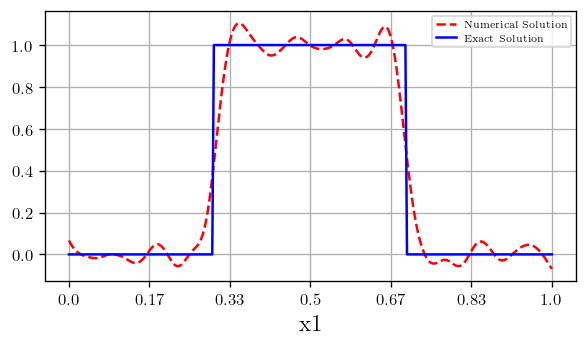

In [38]:
lam=w_store[:,2]
print('正则化参数：',lamb_regu[2]**2)
S_test_num,S_test_true,S_l_inf1,S_l_21,g_S=error_general_ada.test(models,[],[],M,Qx,Qy,lam,af,[],[],True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],center_true,r_true,f_circle,1,device)


## M=1600

In [45]:
M=1600
af="Tanh"   #先用tanh
R_m=20
cupy_device= 2
#models = net_2D_shape.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
models = net_2D_shape.local_rep(2,1,1,M,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],R_m_for_init=R_m,af=af,Shape=[],device=device).to(device)

/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


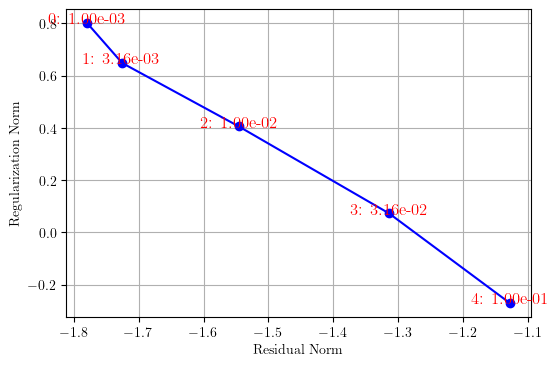

第 0 次迭代的train误差：


In [46]:
iter_int= 1
delta=10**(-3)
nx=100
lamb_regu=np.logspace(-3,-1,5)
Qx,Qy=150,150
af="Tanh"
cells_store,all_points_0,w_store=ada_int(iter_int,delta,cells,nx,models,M,af,kk,F,tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_low,r_upper,center_true,r_true,f_circle,points_b,lamb_regu,Qx,Qy,device,cupy_device)

正则化参数： 0.0001


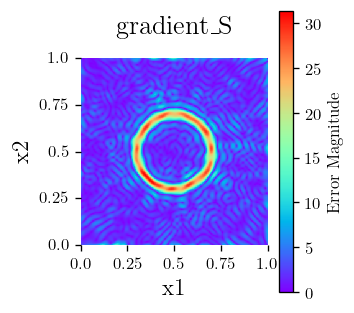

S_l_inf= 1.5616457460607969 S_L_2= 0.07255833684740622 S_l_2= 0.20560871599561295


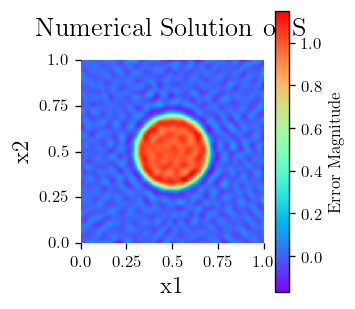

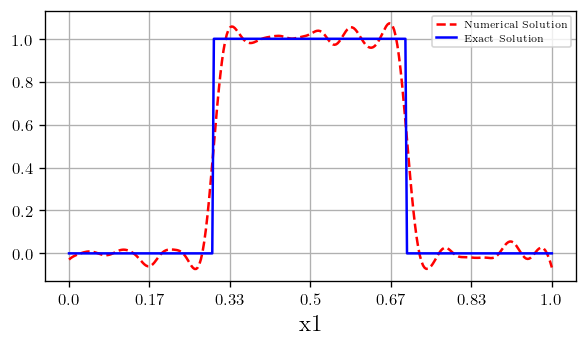

In [50]:
lam=w_store[:,2]
print('正则化参数：',lamb_regu[2]**2)
S_test_num,S_test_true,S_l_inf1,S_l_21,g_S=error_general_ada.test(models,[],[],M,Qx,Qy,lam,af,[],[],True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],center_true,r_true,f_circle,1,device)


## M=3200

In [51]:
M=3200
af="Tanh"   #先用tanh
R_m=20
cupy_device= 2
#models = net_2D_shape.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
models = net_2D_shape.local_rep(2,1,1,M,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],R_m_for_init=R_m,af=af,Shape=[],device=device).to(device)

/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


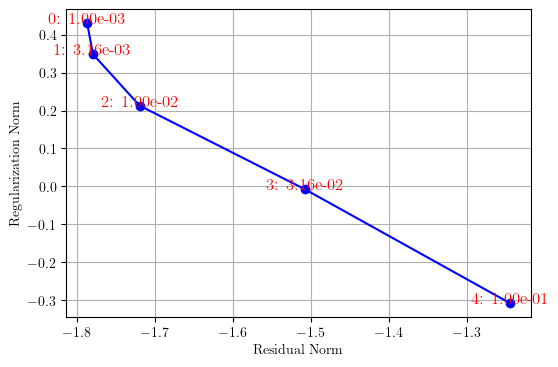

第 0 次迭代的train误差：


In [52]:
iter_int= 1
delta=10**(-3)
nx=100
lamb_regu=np.logspace(-3,-1,5)
Qx,Qy=150,150
af="Tanh"
cells_store,all_points_0,w_store=ada_int(iter_int,delta,cells,nx,models,M,af,kk,F,tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_low,r_upper,center_true,r_true,f_circle,points_b,lamb_regu,Qx,Qy,device,cupy_device)

正则化参数： 0.0001


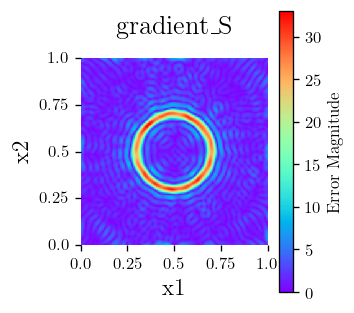

S_l_inf= 1.5633312504066348 S_L_2= 0.06796855141298028 S_l_2= 0.19260263108696446


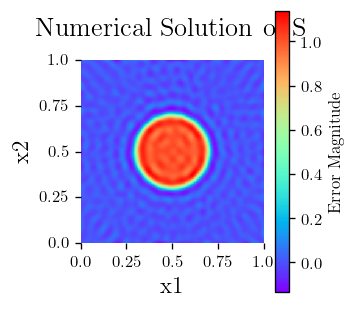

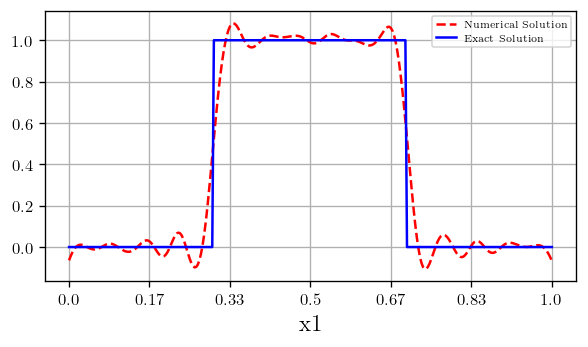

In [55]:
lam=w_store[:,2]
print('正则化参数：',lamb_regu[2]**2)
S_test_num,S_test_true,S_l_inf1,S_l_21,g_S=error_general_ada.test(models,[],[],M,Qx,Qy,lam,af,[],[],True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],center_true,r_true,f_circle,1,device)


## M=6400

In [56]:
M=6400
af="Tanh"   #先用tanh
R_m=20
cupy_device= 2
#models = net_2D_shape.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
models = net_2D_shape.local_rep(2,1,1,M,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],R_m_for_init=R_m,af=af,Shape=[],device=device).to(device)

/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


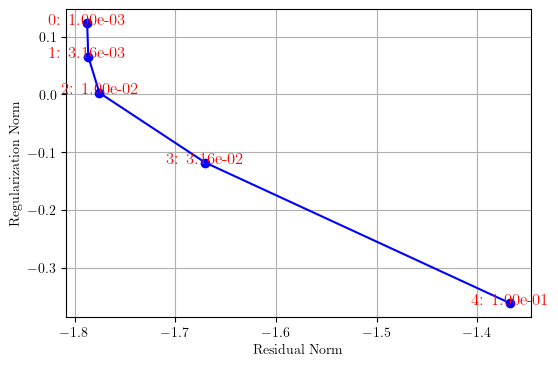

第 0 次迭代的train误差：


In [57]:
iter_int= 1
delta=10**(-3)
nx=100
lamb_regu=np.logspace(-3,-1,5)
Qx,Qy=150,150
af="Tanh"
cells_store,all_points_0,w_store=ada_int(iter_int,delta,cells,nx,models,M,af,kk,F,tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_low,r_upper,center_true,r_true,f_circle,points_b,lamb_regu,Qx,Qy,device,cupy_device)

正则化参数： 0.0001


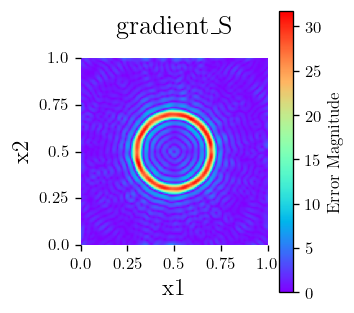

S_l_inf= 1.4819447358251867 S_L_2= 0.06545115247345486 S_l_2= 0.185469072269415


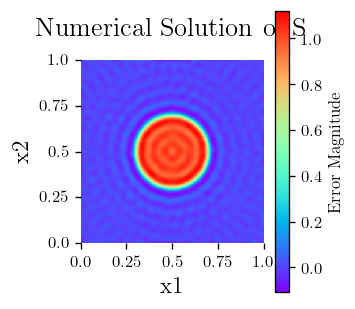

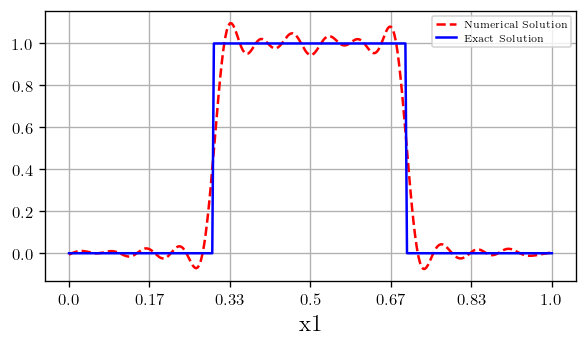

In [59]:
lam=w_store[:,2]
print('正则化参数：',lamb_regu[2]**2)
S_test_num,S_test_true,S_l_inf1,S_l_21,g_S=error_general_ada.test(models,[],[],M,Qx,Qy,lam,af,[],[],True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],center_true,r_true,f_circle,1,device)
